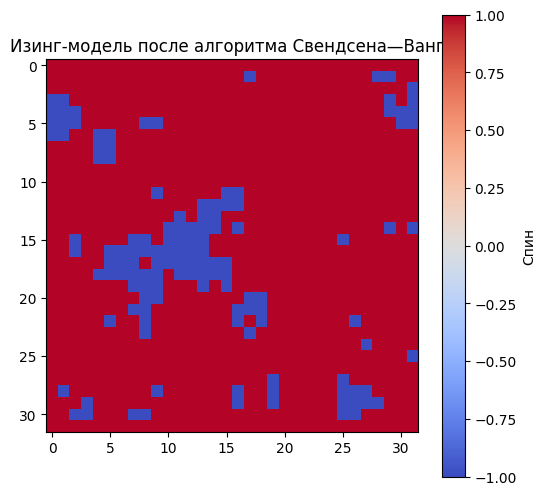

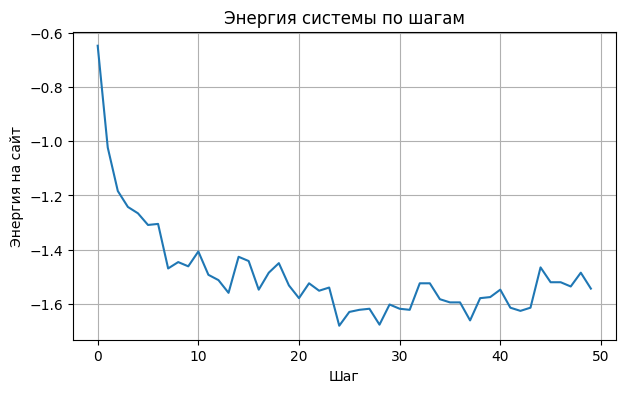

In [4]:
# Кластерный метод Монте-Карло — это семейство алгоритмов, где система обновляется не по одному элементу, а целыми кластерами связанных объектов.
# В физике это особенно известно по алгоритмам Вольфа и Свендсена—Ванга: сначала строятся кластеры одинаково ориентированных спинов, а потом переворачивается сразу весь кластер.
# Алгоритм Свендсена—Ванга: вся решетка разбивается на множество кластеров, и каждый кластер переворачивается с вероятностью 1/2
# Алгоритм Вольфа: строится один кластер, начиная с одного случайно выбранного спина, после чего он переворачивается целиком.
# p = 1 - exp(-2J/T) — вероятность связать соседние одинаковые спины в кластер.
#
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

def neighbors(i, j, L):# Штука чтобы возвращать соседей 
    return [((i - 1) % L, j), ((i + 1) % L, j), (i, (j - 1) % L), (i, (j + 1) % L)]# верхний , нижний  , левый , правый соседи.

def swendsen_wang_step(spins, T, J=1.0):# шаг J=1.0 — константа взаимодействия, по умолчанию равна 1.
    L = spins.shape[0]
    p = 1.0 - np.exp(-2.0 * J / T)# вероятность свзяать ближайших челов в кластер !!!!

    visited = np.zeros((L, L), dtype=bool)# записывает посещение того или иного кластера 
    new_spins = spins.copy() # записываються все конфигурации 

    for i in range(L):#  все вложенный цикл поиска соседей и обьединения в кластеры
        for j in range(L):
            if visited[i, j]:
                continue

            cluster = []
            queue = deque([(i, j)])
            visited[i, j] = True
            spin_value = spins[i, j]

            while queue:
                x, y = queue.popleft()
                cluster.append((x, y))

                for nx, ny in neighbors(x, y, L):
                    if not visited[nx, ny] and spins[nx, ny] == spin_value:
                        if np.random.rand() < p:
                            visited[nx, ny] = True
                            queue.append((nx, ny))

            if np.random.rand() < 0.5:
                for x, y in cluster:
                    new_spins[x, y] *= -1

    return new_spins

def total_energy(spins, J=1.0): # Считаем полную энергию системы 
    L = spins.shape[0]
    E = 0
    for i in range(L):
        for j in range(L):
            E -= J * spins[i, j] * (spins[(i + 1) % L, j] + spins[i, (j + 1) % L])
    return E

# Параметры
L = 32
T = 2.2
steps = 50

# Начальная конфиг
spins = np.random.choice([-1, 1], size=(L, L))

energies = []

for _ in range(steps):
    spins = swendsen_wang_step(spins, T)
    energies.append(total_energy(spins) / (L * L))

# картинка графика
plt.figure(figsize=(6, 6))
plt.imshow(spins, cmap='coolwarm', interpolation='nearest')
plt.title('Изинг-модель после алгоритма Свендсена—Ванга')
plt.colorbar(label='Спин')
plt.show()

# Энергия и шаг 
plt.figure(figsize=(7, 4))
plt.plot(energies)
plt.title('Энергия системы по шагам')
plt.xlabel('Шаг')
plt.ylabel('Энергия на сайт')
plt.grid(True)
plt.show()
